# <center>Лабораторна робота №3. <br> Візуальний аналіз даних про публікації на сайті Хабрахабр</center>

**Заповніть код в клітинках**

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

## Завантаження і знайомство з даними

Для роботи вам знадобляться поепердньо оброблені дані з платформи kaggle (https://www.kaggle.com/c/howpop-habrahabr-favs).

Доступ до даних на google drive, якщо ви відкриваєте блокнот в google colab, а не на PC, можна отримати шляхом монтування google drive

In [42]:
# Локальні дані знаходяться в lab3/data/.

In [43]:
from pathlib import Path
data_folder = Path("data")
if not (data_folder / "howpop_train.csv").exists():
    data_folder = Path("lab3/data")

In [44]:
df = pd.read_csv(data_folder / "howpop_train.csv")

In [45]:
df.shape

(134137, 17)

In [46]:
df.head(3).T

,0,1,2
url,https://habrahabr.ru/post/18284/,https://habrahabr.ru/post/18285/,https://habrahabr.ru/post/18286/
domain,habrahabr.ru,habrahabr.ru,habrahabr.ru
post_id,18284,18285,18286
published,2008-01-01 18:19:00,2008-01-01 18:30:00,2008-01-01 18:34:00
author,@Tapac,@DezmASter,@DezmASter
flow,develop,design,design
polling,False,False,False
content_len,4305,7344,8431
title,Новогодний подарок блоггерам — WordPress 2.3.2,"Сумасшедшие яйца, или сервис для отслеживания ...","Сумасшедшие яйца, или сервис для отслеживания ..."
comments,0,1,47


Позбавимося відразу від змінних, назви яких закінчуються на `_lognorm` (потрібні для змагань на Kaggle). Виберемо їх за допомогою `filter()` і видаимо `drop`-ом:

In [47]:
df.drop(filter(lambda c: c.endswith('_lognorm'), df.columns), 
        axis = 1,       # axis = 1: столвбці 
        inplace = True) # позбавляє від необхідності зберігати датасет

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,134137.0,181307.054265,81766.350702,18284.0,115565.0,182666.0,257401.0,314088.0
content_len,134137.0,7516.929699,8724.771640,1.0,2179.0,4949.0,9858.0,352471.0
comments,134137.0,39.625994,62.398958,0.0,7.0,19.0,48.0,2266.0
favs,134137.0,71.999866,145.854135,0.0,8.0,27.0,78.0,8718.0
views,134137.0,16631.013084,31479.819691,3.0,2100.0,7600.0,18700.0,1730000.0
votes_plus,133566.0,35.536888,42.461073,0.0,11.0,22.0,45.0,1466.0
votes_minus,133566.0,8.050035,11.398282,0.0,2.0,5.0,10.0,445.0


In [49]:
df.describe(include = ['object', 'bool'] # бінарні і категоріальні змінні
           ).T

,count,unique,top,freq
url,134137,134137,https://habrahabr.ru/post/18284/,1
domain,134137,2,habrahabr.ru,97048
published,134137,130291,2011-06-14 15:52:00,39
author,97657,22077,@alizar,5292
flow,97048,6,develop,53318
polling,134137,2,False,129412
title,134137,133628,"Интересные события, произошедшие в выходные",56


In [50]:
# налаштування зовнішнього вигляду графіків в seaborn
sns.set_style("dark")
sns.set_palette("RdBu")
sns.set_context("notebook", font_scale = 1.5, 
                rc = { "figure.figsize" : (15, 5), "axes.titlesize" : 18 })

Стовбець **`published`** (час публікації) містить рядки. Щоб ми мали змогу працювати з цими даними як з датою/часом публікації, приведемо їх до типу `datetime`:

In [51]:
print(df.published.dtype)
df['published'] = pd.to_datetime(df.published, yearfirst = True)
print(df.published.dtype)

object
datetime64[ns]


Створимо декілька стовбців на основі даних про час публікації:

In [52]:
df['year'] = [d.year for d in df.published]
df['month'] = [d.month for d in df.published]

df['dayofweek'] = [d.isoweekday() for d in df.published]
df['hour'] = [d.hour for d in df.published]

-----
Відтепер Ваша черга. В кожному пункті пропонується побудувати картинку і з її допомогою відповісти на питання. Звичано, можна спробувати відповісти на всі питання лише використовуючи Pandas, без картинок, але ми радимо Вам потренуватися будувати (красиві) візуалізації.   

## 1\. В якому місяці (і якого року) було більше всього публікацій?

* березень 2016
* березень 2015
* квітень 2015
* квітень 2016

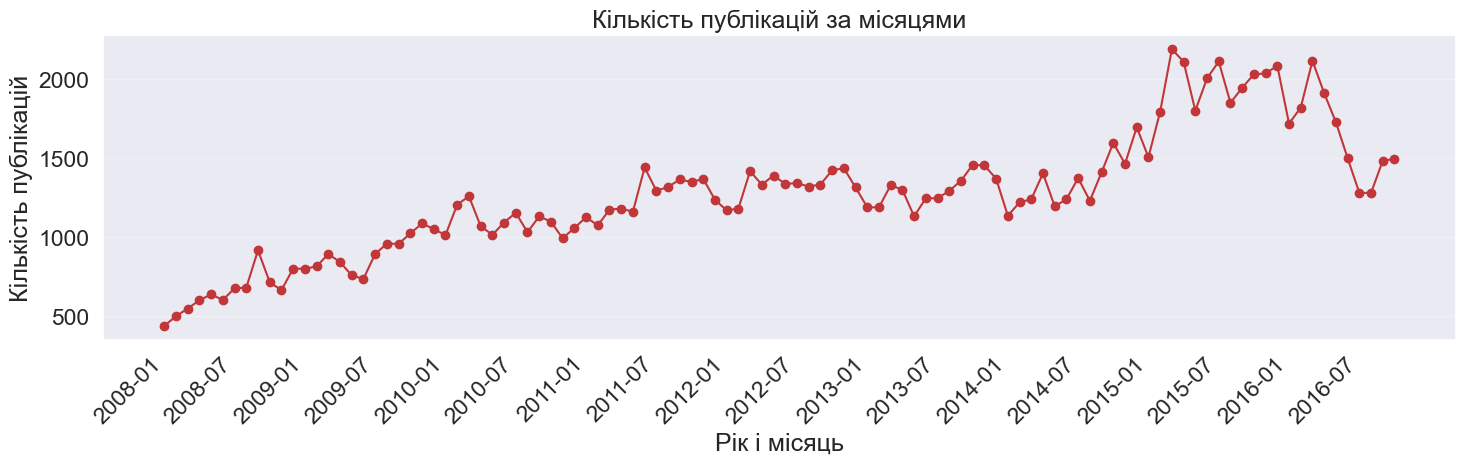

Найбільше публікацій: (np.int64(2015), np.int64(3))


In [53]:
posts_by_month = df.groupby(['year', 'month']).size()
period_labels = [f'{year}-{month:02d}' for year, month in posts_by_month.index]
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(range(len(posts_by_month)), posts_by_month.values, marker='o', linewidth=1.5)
ax.set_xticks(range(0, len(posts_by_month), 6))
ax.set_xticklabels(period_labels[::6], rotation=45, ha='right')
ax.set_title('Кількість публікацій за місяцями')
ax.set_xlabel('Рік і місяць')
ax.set_ylabel('Кількість публікацій')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print('Найбільше публікацій:', posts_by_month.idxmax())

## 2\. Проаналізуйте публікації в месяці з попереднього питання

Виберіть один чи декілька варіантів:

* Один чи декілька днів сильно виділяються із загальної картини
* На хабрі _завжди_ більше статей, ніж на гіктаймсі
* По суботам на гіктаймс і на хабрахабр публікують приблизно одинакову кількість статей

Підказки: побудуйте графік залежності числа публікацій від дня; використовуйте параметр `hue`; не переймайтесь сильно з відповідями і не шукайте прихованого змісту :)

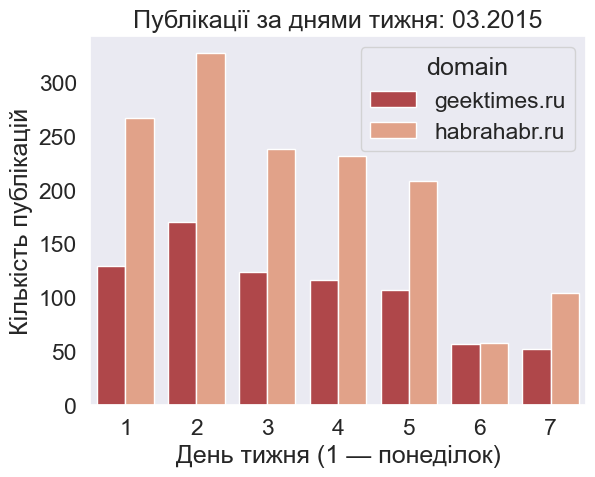

,dayofweek,domain,posts
0,1,geektimes.ru,129
1,1,habrahabr.ru,267
2,2,geektimes.ru,170
3,2,habrahabr.ru,327
4,3,geektimes.ru,124
5,3,habrahabr.ru,238
6,4,geektimes.ru,116
7,4,habrahabr.ru,232
8,5,geektimes.ru,107
9,5,habrahabr.ru,208


In [54]:
peak_year, peak_month = posts_by_month.idxmax()
peak_data = df[(df['year'] == peak_year) & (df['month'] == peak_month)]
daily_domain_counts = peak_data.groupby(['dayofweek', 'domain']).size().reset_index(name='posts')
sns.barplot(data=daily_domain_counts, x='dayofweek', y='posts', hue='domain')
plt.title(f'Публікації за днями тижня: {peak_month:02d}.{peak_year}')
plt.xlabel('День тижня (1 — понеділок)')
plt.ylabel('Кількість публікацій')
plt.show()
daily_domain_counts

## 3\. Коли найкраще всього опублікувати статтю?

* Більш всього переглядів набирають статті, опубліковані в 12 годин дня
* В опублікованих о 10-й ранку постів більше всього коментарів
* Більше всього переглядів набирають статтті, опубліковані в 6 годин ранку
* Максимальне число коментарів на гіктаймсі набрала стаття, опублікована в 9 годин вечора
* На хабрі денні статті комментують частіше, ніж вечірні

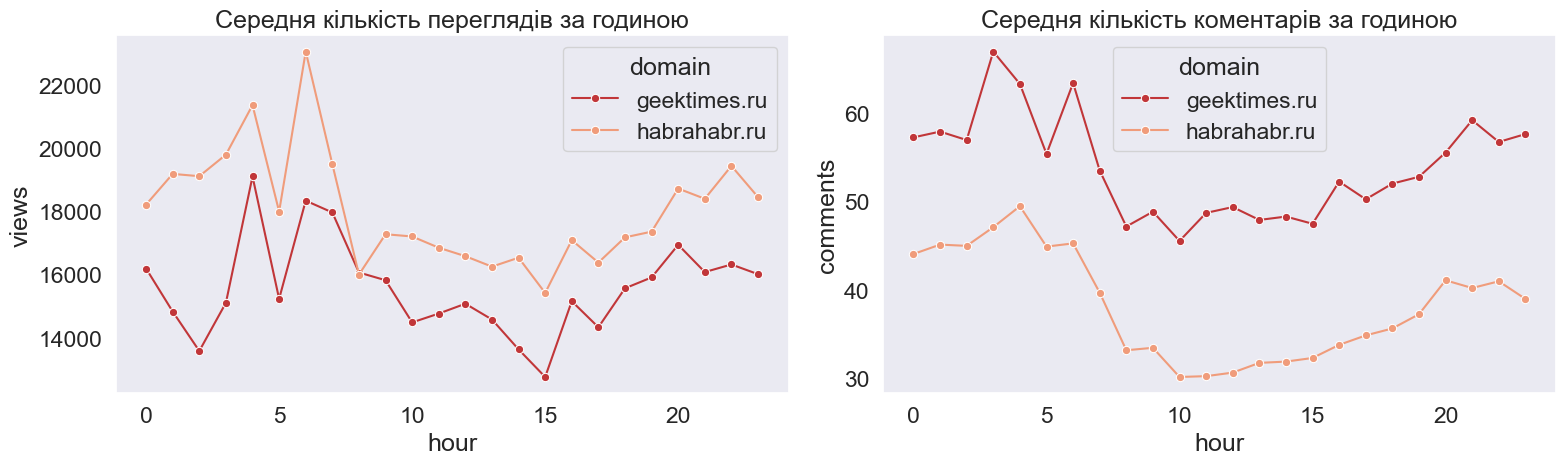

domain      habrahabr.ru
hour                   6
views       23056.691045
comments       45.240299
Name: 30, dtype: object

,hour,comments,title
38763,2,2266,Как раздавать инвайты на Google+


In [55]:
hour_stats = df.groupby(['domain', 'hour'])[['views', 'comments']].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hour_stats, x='hour', y='views', hue='domain', marker='o', ax=axes[0])
axes[0].set_title('Середня кількість переглядів за годиною')
sns.lineplot(data=hour_stats, x='hour', y='comments', hue='domain', marker='o', ax=axes[1])
axes[1].set_title('Середня кількість коментарів за годиною')
plt.tight_layout()
plt.show()
display(hour_stats.loc[hour_stats['views'].idxmax()])
display(df.loc[df['domain'].eq('geektimes.ru')].sort_values('comments', ascending=False).head(1)[['hour', 'comments', 'title']])

## 4\. Кого з топ-20 авторів частіше всього мінусують?

* @Mordatyj
* @Mithgol
* @alizar
* @ilya42

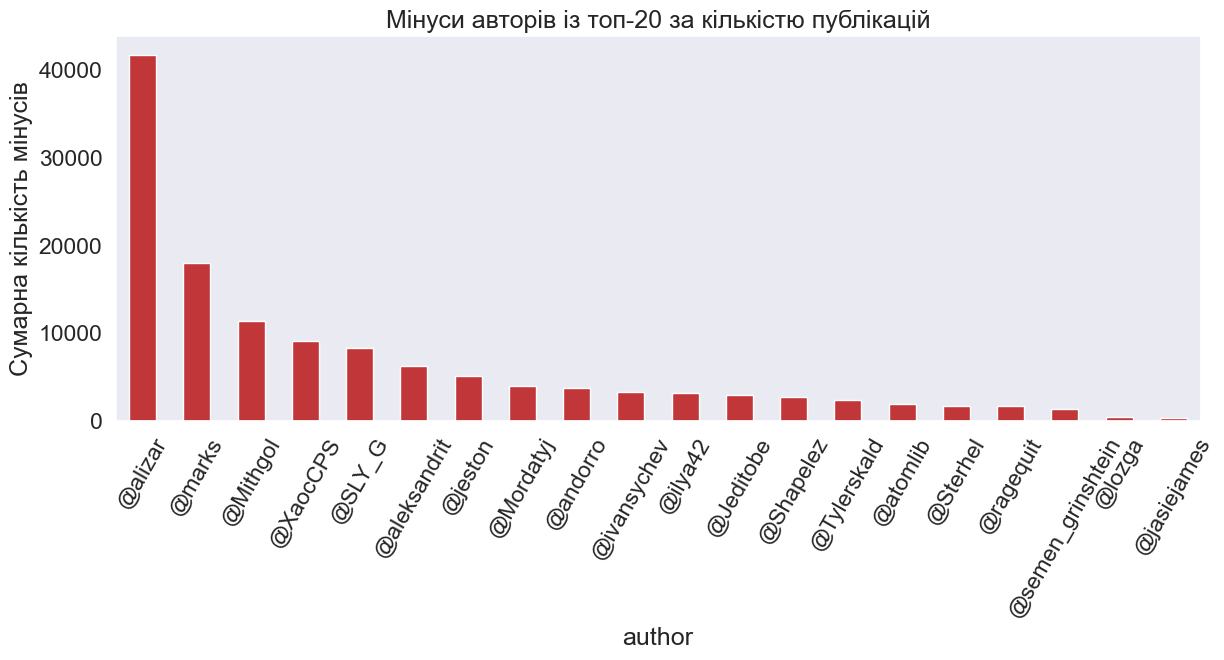

Автор, якого мінусують найчастіше: @alizar


author
@alizar              41734.0
@marks               18059.0
@Mithgol             11367.0
@XaocCPS              9111.0
@SLY_G                8293.0
@aleksandrit          6294.0
@jeston               5117.0
@Mordatyj             4057.0
@andorro              3796.0
@ivansychev           3373.0
@ilya42               3183.0
@Jeditobe             2985.0
@Shapelez             2770.0
@Tylerskald           2384.0
@atomlib              1988.0
@Sterhel              1786.0
@ragequit             1784.0
@semen_grinshtein     1367.0
@lozga                 484.0
@jasiejames            323.0
Name: votes_minus, dtype: float64

In [56]:
top_authors = df['author'].value_counts().head(20).index
minus_by_author = df[df['author'].isin(top_authors)].groupby('author')['votes_minus'].sum().sort_values(ascending=False)
minus_by_author.plot.bar(figsize=(14, 5), title='Мінуси авторів із топ-20 за кількістю публікацій')
plt.ylabel('Сумарна кількість мінусів')
plt.xticks(rotation=60)
plt.show()
print('Автор, якого мінусують найчастіше:', minus_by_author.idxmax())
minus_by_author

## 5\. Порівняйте суботи і понеділки

Чи правда, що по суботам автори пишуть в основному вдень, а по понеділкам — в основному вечером?

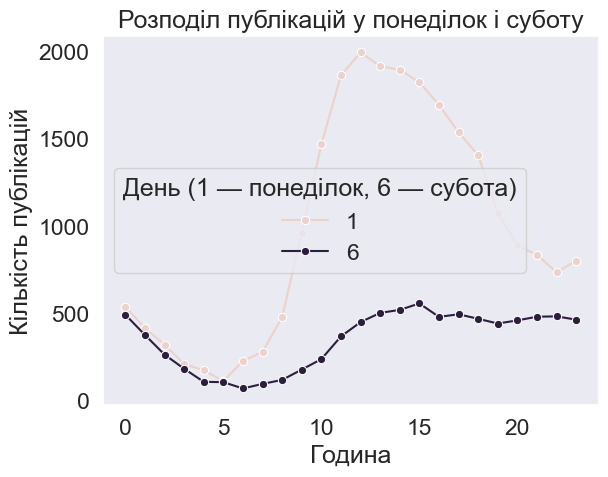

dayofweek,1,6
hour,,
0,537,492
1,415,376
2,320,263
3,209,182
4,173,107
5,111,105
6,226,69
7,279,95
8,477,118


Пікова година в суботу: 15
Пікова година в понеділок: 12
Твердження правильне: False


In [57]:
weekend_monday = df[df['dayofweek'].isin([1, 6])].copy()
hour_day_counts = weekend_monday.groupby(['dayofweek', 'hour']).size().reset_index(name='posts')
sns.lineplot(data=hour_day_counts, x='hour', y='posts', hue='dayofweek', marker='o')
plt.title('Розподіл публікацій у понеділок і суботу')
plt.xlabel('Година')
plt.ylabel('Кількість публікацій')
plt.legend(title='День (1 — понеділок, 6 — субота)')
plt.show()
display(hour_day_counts.pivot(index='hour', columns='dayofweek', values='posts').fillna(0).astype(int))
saturday_peak_hour = hour_day_counts.loc[hour_day_counts['dayofweek'].eq(6)].set_index('hour')['posts'].idxmax()
monday_peak_hour = hour_day_counts.loc[hour_day_counts['dayofweek'].eq(1)].set_index('hour')['posts'].idxmax()
saturday_is_day = 9 <= saturday_peak_hour < 18
monday_is_evening = 18 <= monday_peak_hour < 24
print('Пікова година в суботу:', saturday_peak_hour)
print('Пікова година в понеділок:', monday_peak_hour)
print('Твердження правильне:', saturday_is_day and monday_is_evening)